# Getting started

## Installation

To install the last version of `ugropy` uploaded to [PyPI](https://pypi.org/project/ugropy/) simply do:

```
pip install ugropy
```

If you are working on a google colab use:

```
%pip install ugropy
```

If you are a developer that want's to contribute to `ugropy`, you can install
it in development mode by cloning the repository and running:

```
pip install -e .
```

## Citing ugropy

If you use `ugropy` in your research, please cite the following [article](https://doi.org/10.1021/acs.iecr.5c02552):

```
@article{brandolin2025ugropy,
  title={Ugropy: An Extensible Python Package for Thermodynamic Model Functional Group Identification via Mathematical Optimization},
  author={Brandol{\'\i}n, Salvador E and Benelli, Federico E and Magario, Ivana and Scilipoti, Jos{\'e} A},
  journal={Industrial \& Engineering Chemistry Research},
  volume={64},
  number={35},
  pages={17217--17227},
  year={2025},
  publisher={ACS Publications},
  doi = {10.1021/acs.iecr.5c02552}
}
```

## About the algorithm

Before all, the `ugropy`'s algorithm rely on three major dependency libraries:
- [RDKit](https://www.rdkit.org/): for handling chemical structures and performing substructure searches.
- [PuLP](https://github.com/coin-or/pulp): for formulating and solving the integer optimization problems.
- [PubChemPy](https://github.com/mcs07/PubChemPy): for retrieving chemical information (SMILES) from the PubChem database.

Without the capabilities of these libraries, `ugropy` would not be able to
perform its core functions effectively. `RDKit` allows for efficient
manipulation of chemical structures, while `PuLP` provides a powerful framework
for solving the optimization problems that arise in functional group
identification. `PubChemPy` enables access to SMILES strings from the molecules
names.

`ugropy`'s algorithm is based on the concept of fragmentation, which involves
selecting a set of fragments (functional groups) that can be used to represent
the molecule from a structures list.

The `RDKit` library is used to perform substructure searches, for example,
let's imagine that we have a very simple fragmentation model that only detects
the presence of methyl (CH3) and ethyl (CH2) fragments.

In [7]:
from rdkit import Chem


# Definition of the fragments of our model
ch3 = Chem.MolFromSmarts("[CX4H3]")
ch2 = Chem.MolFromSmarts("[CX4H2]")

On the majority fragmentation models, usually, we have to specify which
fragments are used to represent a molecule and the number of times that
fragments are present in the molecule. For example, if we want to fragment
the n-hexane molecule with our simple fragmentation model, we can simply do
it with the `RDKit` library as follows:

In [8]:
# Molecule to fragment
hexane = Chem.MolFromSmiles("CCCCCC")

In [9]:
ch3_detections = hexane.GetSubstructMatches(ch3)

ch3_detections

((0,), (5,))

In [10]:
ch2_detections = hexane.GetSubstructMatches(ch2)

ch2_detections

((1,), (2,), (3,), (4,))

`RDKit` is returning a tuple of tuples for each fragment, where each inner
tuple contains the indices of the atoms that match the fragment. The length of
the outer tuple indicates how many times the fragment is present in the
molecule. In this case, we have 2 methyl groups and 4 ethyl groups in the
n-hexane molecule. For that we can directly build a dictionary that represents
the result of the n-hexane fragmentation with our simple model:

In [11]:
solution = {
    "CH3": len(ch3_detections),
    "CH2": len(ch2_detections),
}

solution

{'CH3': 2, 'CH2': 4}

This simple molecule with this simple fragmentation model was the start of the
`ugropy` development:

    "Well... now we just need to add all the fragments of a model like UNIFAC,
    make a direct detection with RDKit for each one and that's all... right?".

Well, no. The problem is that, some fragments can be overlapped in the
molecule's atoms by doing a direct detection. For example, let's analyze the
following molecule:

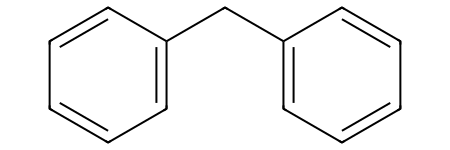

In [12]:
smiles = "c1ccccc1Cc2ccccc2"

molecule = Chem.MolFromSmiles(smiles)

molecule

In many fragmentation models like UNIFAC, there are fragments to differentiate
between aliphatic and aromatic carbons. Let's imagine the following
fragmentation model:

In [13]:
# Definition of the fragments of our model

# Aliphatic CH2
ch2 = Chem.MolFromSmarts("[CX4H2]")

# Aromatic CH
ach = Chem.MolFromSmarts("[cH]")

# Aromatic C without H
ac = Chem.MolFromSmarts("[cH0]")

# Aromatic C bonded with aliphatic CH2
acch2 = Chem.MolFromSmarts("[cH0]([CX4H2])")